# Orange County Analysis

In [1]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    add_standardized_race,
    census_rollup,
    policing_rates,
    prosecution_rates_by_statute_level,
    visualize_policing,
    visualize_prosecution,
    save_policing,
    save_prosecution
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [ ]:
# Load in policing data
original_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2022_2024.csv")

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

<positron-console-cell-2>:2: DtypeWarning: Columns (0: time_of_stop, 1: school_code, 2: school_name, 3: ros_warning_cds, 4: ros_citation_cds, 5: ros_in_field_cite_release_cds, 6: ros_custodial_wout_warrant_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

KeyboardInterrupt: 

In [ ]:
# Load in census data
census = load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Policing Analysis

In [ ]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
policing["disc_hit"] = policing["disc_search"] & policing["contraband_any"].eq(1)

policing_analysis = policing_rates(policing, census_coarse)
policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000"
0,2020,Asian,2356,76,22,0.032258,0.289474,699124,3.369932,0.108707
1,2020,Black/African American,1381,140,43,0.101376,0.307143,49304,28.009898,2.839526
2,2020,Hispanic/Latino,11782,1509,427,0.128077,0.282969,1086834,10.840662,1.388437
3,2020,Other,2632,104,32,0.039514,0.307692,153072,17.194523,0.679419
4,2020,White,16917,1385,527,0.081870,0.380505,1198655,14.113319,1.155462
5,2021,Asian,5136,257,80,0.050039,0.311284,699124,7.346336,0.367603
6,2021,Black/African American,3732,346,79,0.092712,0.228324,49304,75.693656,7.017686
7,2021,Hispanic/Latino,42497,4614,1314,0.108572,0.284785,1086834,39.101648,4.245359
8,2021,Other,6617,188,52,0.028412,0.276596,153072,43.228023,1.228180
9,2021,White,28520,2216,882,0.077700,0.398014,1198655,23.793335,1.848739


## Prosecution Rates

In [ ]:
# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

# Create race x year x statute_level prosecution summary table
prosecution_analysis = prosecution_rates_by_statute_level(prosecution)

prosecution_analysis

,Canonical Race,Year,statute_level,Total Charges,Enhancement Rate
0,Asian,2021,Felony,1251,0.000799
1,Asian,2021,Misdemeanor,2768,0.142702
2,Asian,2022,Felony,1090,0.003670
3,Asian,2022,Misdemeanor,2289,0.174749
4,Asian,2023,Felony,876,0.001142
5,Asian,2023,Misdemeanor,1325,0.163774
6,Black/African American,2021,Felony,1689,0.008289
7,Black/African American,2021,Misdemeanor,3014,0.112143
8,Black/African American,2022,Felony,2195,0.006834
9,Black/African American,2022,Misdemeanor,2881,0.112114


# Visualizations

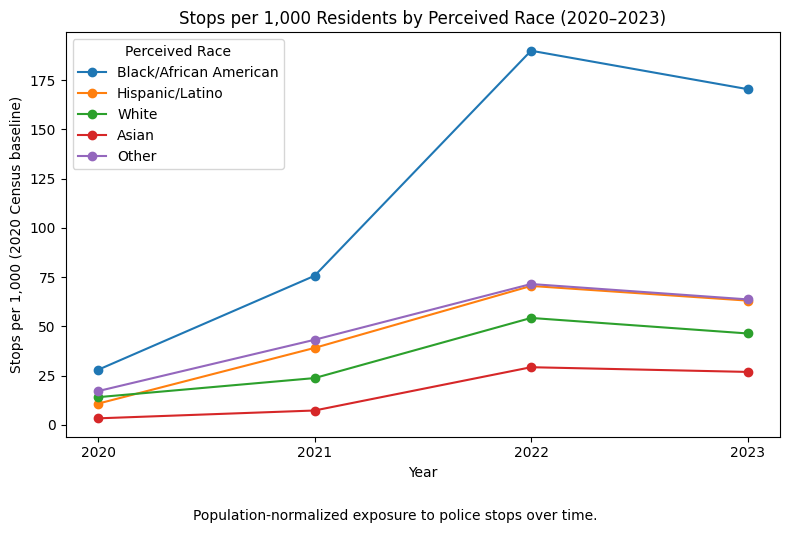

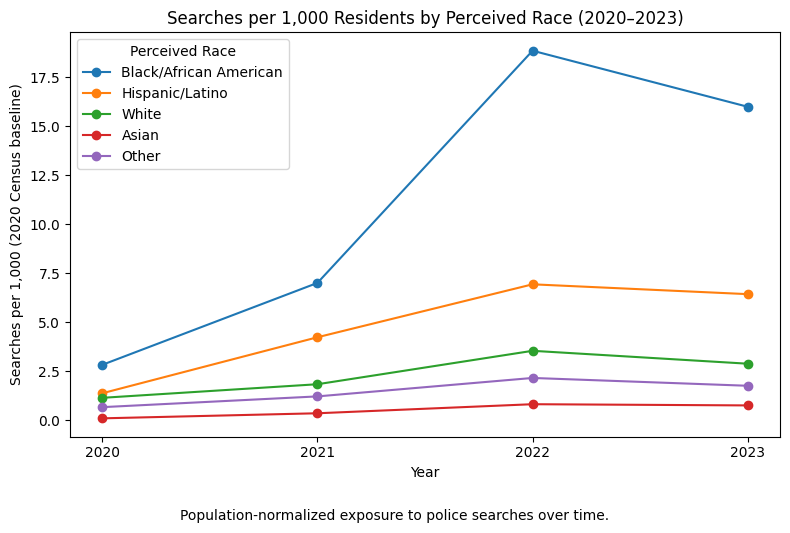

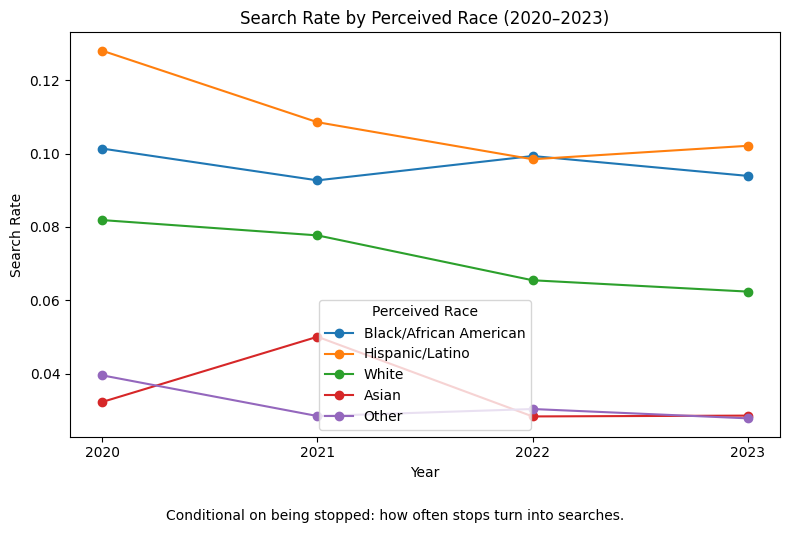

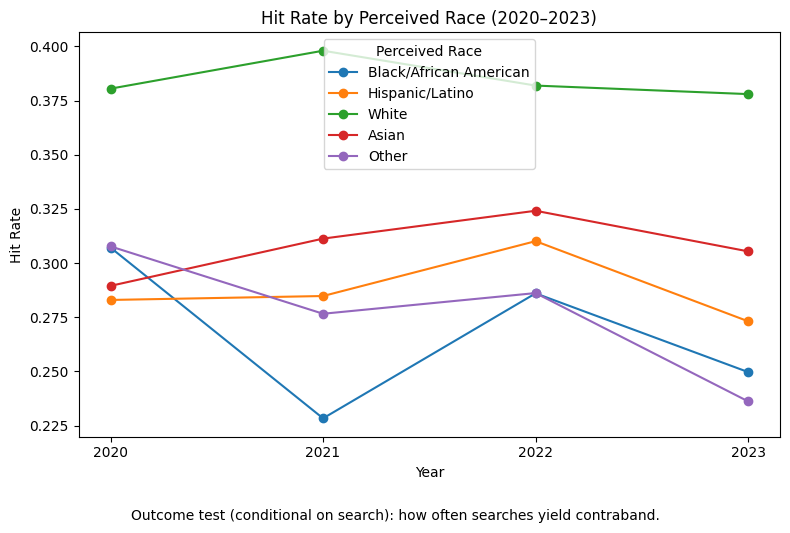

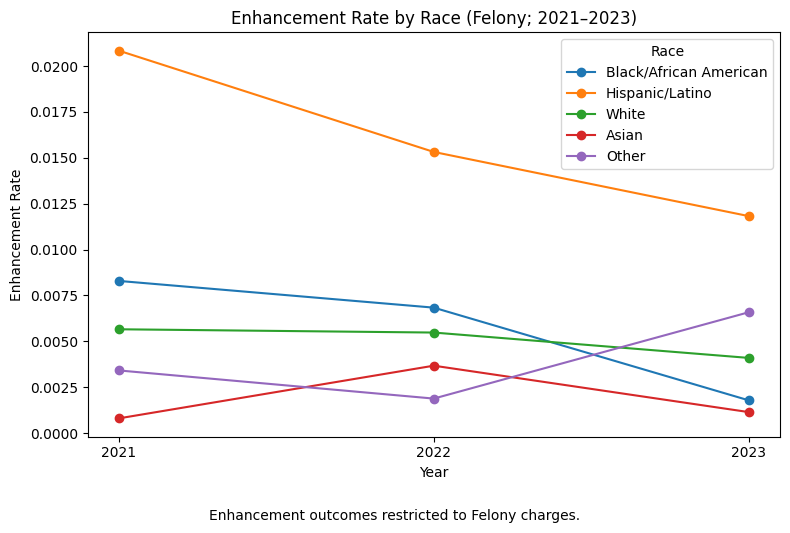

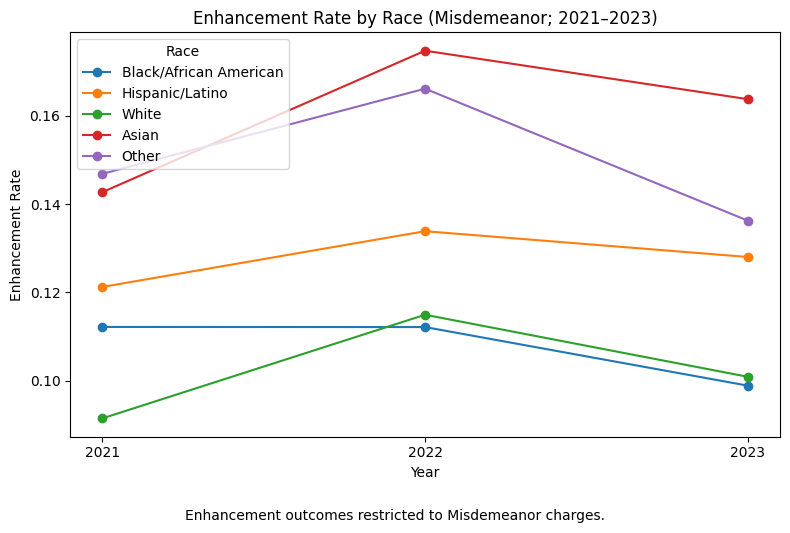

In [ ]:
visualize_policing(policing_analysis)
visualize_prosecution(prosecution_analysis)

In [ ]:
# Saves the visualizations
#save_policing(policing_analysis)
#save_prosecution(prosecution_analysis)

# Saves the tables
#with open("../output/policing_analysis.tex", "w") as f:
#    f.write(policing_analysis.to_latex(index=False))

#with open("../output/prosecution_analysis.tex", "w") as f:
#    f.write(prosecution_analysis.to_latex(index=False))

# Handling Multiple Search Bases

In [ ]:
# Check how many stops conduct searches but with no recorded reason

# Condition: search occurred but search_type says "No search basis"
mask = (policing["action_any_search"]) & (policing["search_type"] == "No search basis")

# Number of such rows
num_problem = mask.sum()

# Total rows (or you can restrict denominator — see below)
total_rows = len(policing)

percent_problem = num_problem / total_rows

print("Count:", num_problem)
print(f"Percent of all rows: {percent_problem:.2%}")

# So negligible number of searches with no search basis recorded

Count: 7
Percent of all rows: 0.00%


In [ ]:
# Check how many stops have more than one search basis

search_basis_cols = [
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory"
]

policing["num_search_bases"] = policing[search_basis_cols].sum(axis=1)
num_multi_basis = (policing["num_search_bases"] > 1).sum()
percent_multi = (policing["num_search_bases"] > 1).mean()
print(f"Only {percent_multi:.2%} of stops ({num_multi_basis}) have multiple search bases")

Only 4.99% of stops (23234) have multiple search bases


# Deeper Prosecution Analysis: Control by Charge
See Databot
- Look into why certain groups have higher rates than others – control by types of charges, starting with the most common and grouping the less common ones
- Look at the severity of charges for each group, e.g. 1st, 2nd, 3rd degree
- When get down to individual charges, get standard errors on everything – size points points by number of individuals in that bucket, then add in faint error bars to visualizations